# 21. 장르와 음향 특징

18B의 균형 집합에서 생성기 분류 성능을 장르별로 나누어 보고, Train 특징에 ANOVA를 적용한다. 특징 차이가 장르마다 반복되는지도 확인한다. ANOVA 결과를 SVM의 feature importance로 해석하지 않는다.

## 1. 라이브러리 / 경로 / 입력 로드

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

PROJECT_ROOT = Path("/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project")

SEGMENT_PATH = PROJECT_ROOT / "data/metadata/segment_manifest_10s.csv"
FEATURE_PATH = PROJECT_ROOT / "data/processed/features/handcrafted_features_10s.csv"
MERT_PATH = PROJECT_ROOT / "data/processed/mert/mert95m_v2_layers_float16.npy"

STRICT_TRACKS_PATH = (
    PROJECT_ROOT
    / "results/generator_attribution/balanced_controlled/strict_selected_tracks.csv"
)

HAND_MODEL_PATH = (
    PROJECT_ROOT / "checkpoints/generator_attribution/"
    "generator_attribution_rbf_svm_strict_balanced.joblib"
)

MERT_MODEL_PATH = (
    PROJECT_ROOT / "checkpoints/generator_attribution/"
    "generator_attribution_mert_strict_lr.joblib"
)

RESULT_DIR = PROJECT_ROOT / "results/generator_genre_feature_analysis"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MERT_LAYER = 10

segments = pd.read_csv(SEGMENT_PATH).reset_index(drop=True)
features = pd.read_csv(FEATURE_PATH)
# 배열 캐시를 읽어 저장된 특징과 ID의 순서를 확인한다.
mert_cache = np.load(MERT_PATH, mmap_mode="r")
strict_tracks = pd.read_csv(STRICT_TRACKS_PATH)

hand_artifact = joblib.load(HAND_MODEL_PATH)
mert_artifact = joblib.load(MERT_MODEL_PATH)

print("Segments      :", len(segments))
print("Features      :", len(features))
print("MERT cache    :", mert_cache.shape)
print("Strict tracks :", len(strict_tracks))
print("Hand model    :", HAND_MODEL_PATH.exists())
print("MERT model    :", MERT_MODEL_PATH.exists())

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(segments) == 10077
assert len(features) == 10077
assert mert_cache.shape == (10077, 13, 768)
assert len(strict_tracks) == 1428
assert HAND_MODEL_PATH.exists()
assert MERT_MODEL_PATH.exists()

print("Input QC PASS: True")

Segments      : 10077
Features      : 10077
MERT cache    : (10077, 13, 768)
Strict tracks : 1428
Hand model    : True
MERT model    : True
Input QC PASS: True


## 2. Strict track representations 재구성

In [2]:

segment_meta_cols = set(segments.columns)

extra_meta_cols = {
    "Unnamed: 0",
    "index",
    "cache_index",
    "extraction_success",
    "success",
    "error",
}

feature_cols = [
    c
    for c in features.columns
    if c != "segment_id"
    and c not in segment_meta_cols
    and c not in extra_meta_cols
    and not str(c).startswith("Unnamed:")
    and pd.api.types.is_numeric_dtype(features[c])
]

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(feature_cols) == 266

seg_meta = segments[
    [
        "segment_id",
        "track_sample_id",
        "original_audio",
        "generator",
        "genre",
        "split",
        "label",
    ]
].copy()

merged = seg_meta.merge(
    features[["segment_id"] + feature_cols],
    on="segment_id",
    how="inner",
    validate="one_to_one",
)

selected_ids = set(strict_tracks["track_sample_id"])

strict_seg = merged[merged["track_sample_id"].isin(selected_ids)].copy()

hand_track = strict_seg.groupby("track_sample_id", as_index=False).agg(
    {
        **{
            "original_audio": "first",
            "generator": "first",
            "genre": "first",
            "split": "first",
        },
        **{c: "mean" for c in feature_cols},
    }
)

segments2 = segments.copy()
segments2["cache_index"] = np.arange(len(segments2))

mert_rows = []

for track_id, group in segments2[
    segments2["track_sample_id"].isin(selected_ids)
# 같은 곡의 10초 구간을 묶어 곡 단위 결과를 만든다.
].groupby("track_sample_id"):

    idx = group["cache_index"].to_numpy(dtype=int)

    emb = np.asarray(
        mert_cache[idx, BEST_MERT_LAYER, :],
        dtype=np.float32,
    ).mean(axis=0)

    first = group.iloc[0]

    mert_rows.append(
        {
            "track_sample_id": track_id,
            "original_audio": first["original_audio"],
            "generator": first["generator"],
            "genre": first["genre"],
            "split": first["split"],
            "embedding": emb,
        }
    )

mert_track = pd.DataFrame(mert_rows)

print("Handcrafted rows/dims:", len(hand_track), len(feature_cols))
print("MERT rows/dims       :", len(mert_track), 768)

assert len(hand_track) == 1428
assert len(mert_track) == 1428

print("Strict Representation QC PASS: True")

Handcrafted rows/dims: 1428 266
MERT rows/dims       : 1428 768
Strict Representation QC PASS: True


## 3. Test Genre × Generator 분포

In [3]:

# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
test_hand = hand_track[hand_track["split"] == "test"].reset_index(drop=True)

print("Overall strict genre distribution")
display(hand_track["genre"].value_counts().sort_index().to_frame("tracks"))

print("\nTest Genre × Generator distribution")
genre_gen_test = pd.crosstab(
    test_hand["generator"],
    test_hand["genre"],
)
display(genre_gen_test)

print("\nUnique Test source count by genre")
test_source_genre = test_hand[["original_audio", "genre"]].drop_duplicates()

display(test_source_genre["genre"].value_counts().sort_index().to_frame("test_sources"))

print("Genre Distribution QC PASS: True")

Overall strict genre distribution


,tracks
genre,
Electronic,504
Pop,468
Rock,456



Test Genre × Generator distribution


genre,Electronic,Pop,Rock
generator,,,
acestep,7,5,7
audioldm,7,5,7
brev,7,5,7
diffrhythm,7,5,7
elevenlabs,7,5,7
mubert,7,5,7
musicgen,7,5,7
producer,7,5,7
songgen,7,5,7



Unique Test source count by genre


,test_sources
genre,
Electronic,7
Pop,5
Rock,7


Genre Distribution QC PASS: True


## 4. 장르별 attribution 성능

18-B와 19에서 이미 학습된 **동일 global classifier**를 그대로 사용한다.
장르별로 재학습하지 않는다.

In [4]:
# Handcrafted model
hand_classes = list(hand_artifact["classes"])
hand_encoder = hand_artifact["encoder"]
hand_scaler = hand_artifact["scaler"]
hand_svm = hand_artifact["svm"]

Xh = test_hand[feature_cols].to_numpy(dtype=np.float32)
# Train에서 정한 생성기 레이블 번호를 다른 분할에도 그대로 적용한다.
yh = hand_encoder.transform(test_hand["generator"])

# Validation/Test에는 Train의 표준화 기준만 적용해 정보 누수를 막는다.
hand_scores = hand_svm.decision_function(hand_scaler.transform(Xh))
hand_pred = np.argmax(hand_scores, axis=1)

# MERT model
mert_classes = list(mert_artifact["classes"])
mert_encoder = LabelEncoder().fit(mert_classes)
mert_scaler = mert_artifact["scaler"]
mert_clf = mert_artifact["classifier"]

test_mert = mert_track[mert_track["split"] == "test"].reset_index(drop=True)

Xm = np.stack(test_mert["embedding"].to_numpy()).astype(np.float32)
ym = mert_encoder.transform(test_mert["generator"])

mert_probs = mert_clf.predict_proba(mert_scaler.transform(Xm))
mert_pred = np.argmax(mert_probs, axis=1)


def genre_metrics(meta, y, pred, model_name):
    rows = []

    for genre in sorted(meta["genre"].dropna().unique()):
        mask = meta["genre"].to_numpy() == genre

        yg = y[mask]
        pg = pred[mask]

        rows.append(
            {
                "model": model_name,
                "genre": genre,
                "n_tracks": int(mask.sum()),
                "accuracy": float(accuracy_score(yg, pg)),
                "balanced_accuracy": float(balanced_accuracy_score(yg, pg)),
                "macro_f1": float(
                    f1_score(
                        yg,
                        pg,
                        average="macro",
                        zero_division=0,
                    )
                ),
            }
        )

    return pd.DataFrame(rows)


genre_perf = pd.concat(
    [
        genre_metrics(
            test_hand,
            yh,
            hand_pred,
            "Handcrafted+RBF-SVM",
        ),
        genre_metrics(
            test_mert,
            ym,
            mert_pred,
            "MERT95M+LR",
        ),
    ],
    ignore_index=True,
)

display(genre_perf.round(4))

,model,genre,n_tracks,accuracy,balanced_accuracy,macro_f1
0,Handcrafted+RBF-SVM,Electronic,84,0.6905,0.6905,0.6734
1,Handcrafted+RBF-SVM,Pop,60,0.8000,0.8000,0.7718
2,Handcrafted+RBF-SVM,Rock,84,0.7857,0.7857,0.7780
3,MERT95M+LR,Electronic,84,0.8810,0.8810,0.8767
4,MERT95M+LR,Pop,60,0.9667,0.9667,0.9667
5,MERT95M+LR,Rock,84,0.8690,0.8690,0.8700


## 5. Generator × Genre Recall Matrix

In [5]:
# Generator × Genre Recall Matrix


def generator_genre_recall(
    meta,
    y_true,
    y_pred,
    class_names,
    model_name,
):
    rows = []

    true_names = np.array(class_names)[y_true]
    pred_names = np.array(class_names)[y_pred]

    for generator in class_names:
        for genre in sorted(meta["genre"].dropna().unique()):
            mask = (true_names == generator) & (meta["genre"].to_numpy() == genre)

            n = int(mask.sum())

            recall = float(np.mean(pred_names[mask] == generator)) if n > 0 else np.nan

            rows.append(
                {
                    "model": model_name,
                    "generator": generator,
                    "genre": genre,
                    "n_tracks": n,
                    "recall": recall,
                }
            )

    return pd.DataFrame(rows)


hand_genre_recall = generator_genre_recall(
    test_hand,
    yh,
    hand_pred,
    hand_classes,
    "Handcrafted+RBF-SVM",
)

mert_genre_recall = generator_genre_recall(
    test_mert,
    ym,
    mert_pred,
    mert_classes,
    "MERT95M+LR",
)

gen_genre_recall = pd.concat(
    [hand_genre_recall, mert_genre_recall],
    ignore_index=True,
)

for model_name in gen_genre_recall["model"].unique():
    print("\n", model_name)

    pivot = gen_genre_recall[gen_genre_recall["model"] == model_name].pivot(
        index="generator",
        columns="genre",
        values="recall",
    )

    display(pivot.round(3))


 Handcrafted+RBF-SVM


genre,Electronic,Pop,Rock
generator,,,
acestep,0.857,0.8,0.857
audioldm,0.857,1.0,1.000
brev,0.286,0.0,0.286
diffrhythm,0.857,1.0,1.000
elevenlabs,0.857,0.8,0.857
mubert,0.571,1.0,0.714
musicgen,1.000,1.0,1.000
producer,1.000,0.4,0.714
songgen,0.857,1.0,1.000



 MERT95M+LR


genre,Electronic,Pop,Rock
generator,,,
acestep,1.000,1.0,1.000
audioldm,1.000,1.0,1.000
brev,0.571,0.8,0.571
diffrhythm,0.857,1.0,0.857
elevenlabs,1.000,1.0,1.000
mubert,1.000,1.0,0.857
musicgen,1.000,1.0,1.000
producer,1.000,1.0,0.857
songgen,1.000,1.0,1.000


## 6. 장르 민감도가 큰 Generator

In [6]:
# 장르 민감도가 큰 Generator

rows = []

for (model_name, generator), group in gen_genre_recall.groupby(["model", "generator"]):
    valid = group.dropna(subset=["recall"])

    if len(valid) == 0:
        continue

    best = valid.loc[valid["recall"].idxmax()]
    worst = valid.loc[valid["recall"].idxmin()]

    rows.append(
        {
            "model": model_name,
            "generator": generator,
            "mean_recall": valid["recall"].mean(),
            "best_genre": best["genre"],
            "best_recall": best["recall"],
            "worst_genre": worst["genre"],
            "worst_recall": worst["recall"],
            "genre_recall_range": best["recall"] - worst["recall"],
        }
    )

genre_sensitivity = pd.DataFrame(rows)

display(
    genre_sensitivity.sort_values(
        ["model", "genre_recall_range"],
        ascending=[True, False],
    ).round(4)
)

,model,generator,mean_recall,best_genre,best_recall,worst_genre,worst_recall,genre_recall_range
11,Handcrafted+RBF-SVM,udio,0.4571,Pop,0.8000,Electronic,0.0000,0.8000
7,Handcrafted+RBF-SVM,producer,0.7048,Electronic,1.0000,Pop,0.4000,0.6000
5,Handcrafted+RBF-SVM,mubert,0.7619,Pop,1.0000,Electronic,0.5714,0.4286
10,Handcrafted+RBF-SVM,suno,0.7143,Pop,1.0000,Electronic,0.5714,0.4286
2,Handcrafted+RBF-SVM,brev,0.1905,Electronic,0.2857,Pop,0.0000,0.2857
9,Handcrafted+RBF-SVM,stableaudio,0.7429,Rock,0.8571,Electronic,0.5714,0.2857
1,Handcrafted+RBF-SVM,audioldm,0.9524,Pop,1.0000,Electronic,0.8571,0.1429
3,Handcrafted+RBF-SVM,diffrhythm,0.9524,Pop,1.0000,Electronic,0.8571,0.1429
8,Handcrafted+RBF-SVM,songgen,0.9524,Pop,1.0000,Electronic,0.8571,0.1429
0,Handcrafted+RBF-SVM,acestep,0.8381,Electronic,0.8571,Pop,0.8000,0.0571


## 7. Handcrafted feature group 정의

In [12]:
# Handcrafted feature group 정의


def feature_group(name):
    n = name.lower()

    if n.startswith("mfcc_delta2_"):
        return "Delta2"
    if n.startswith("mfcc_delta_"):
        return "Delta"
    if n.startswith("mfcc_"):
        return "MFCC"
    if "centroid" in n:
        return "Centroid"
    if "bandwidth" in n:
        return "Bandwidth"
    if "rolloff" in n:
        return "Rolloff"
    if "flatness" in n:
        return "Flatness"
    if "contrast" in n:
        return "Contrast"
    if n.startswith("rms") or "_rms" in n:
        return "RMS"
    if n.startswith("zcr") or "zero_cross" in n:
        return "ZCR"

    return "Other"


group_map = pd.DataFrame(
    {
        "feature": feature_cols,
        "group": [feature_group(c) for c in feature_cols],
    }
)

display(group_map["group"].value_counts().to_frame("n_features"))

if "Other" in set(group_map["group"]):
    print("\nOther features:")
    print(
        group_map.loc[
            group_map["group"] == "Other",
            "feature",
        ].tolist()
    )

,n_features
group,
MFCC,80
Delta,80
Delta2,80
Contrast,14
Centroid,2
Bandwidth,2
Rolloff,2
Flatness,2
RMS,2


## 8. Generator-discriminative feature — Train-only ANOVA F-score

주의: 이 값은 **RBF-SVM의 feature importance가 아니다.**

각 feature가 generator class 간 평균 차이를 얼마나 크게 보이는지 나타내는
**univariate discriminative score**다.

In [13]:

# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
train_hand = hand_track[hand_track["split"] == "train"].reset_index(drop=True)

X_train = train_hand[feature_cols].to_numpy(dtype=np.float32)

# Train에서 정한 생성기 레이블 번호를 다른 분할에도 그대로 적용한다.
y_train = hand_encoder.transform(train_hand["generator"])

f_scores, p_values = f_classif(
    X_train,
    y_train,
)

f_scores = np.nan_to_num(
    f_scores,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)

feature_stats = pd.DataFrame(
    {
        "feature": feature_cols,
        "group": [feature_group(c) for c in feature_cols],
        "anova_f": f_scores,
        "p_value": p_values,
    }
)

print("Top 20 individual features")
display(feature_stats.sort_values("anova_f", ascending=False).head(20).round(4))

group_stats = (
    feature_stats.groupby("group", as_index=False)
    .agg(
        n_features=("feature", "size"),
        mean_f=("anova_f", "mean"),
        median_f=("anova_f", "median"),
        max_f=("anova_f", "max"),
    )
    .sort_values("mean_f", ascending=False)
)

print("\nFeature group summary")
display(group_stats.round(4))

Top 20 individual features


,feature,group,anova_f,p_value
260,spectral_contrast_07_mean,Contrast,582.8031,0.0
262,rms_mean,RMS,195.2819,0.0
263,rms_std,RMS,160.7195,0.0
247,spectral_flatness_std,Flatness,158.5983,0.0
24,mfcc_13_mean,MFCC,116.5799,0.0
246,spectral_flatness_mean,Flatness,111.6049,0.0
20,mfcc_11_mean,MFCC,110.0013,0.0
52,mfcc_27_mean,MFCC,107.8927,0.0
10,mfcc_06_mean,MFCC,84.6289,0.0
261,spectral_contrast_07_std,Contrast,82.4844,0.0



Feature group summary


,group,n_features,mean_f,median_f,max_f
7,RMS,2,178.0007,178.0007,195.2819
5,Flatness,2,135.1016,135.1016,158.5983
9,ZCR,2,71.0792,71.0792,75.7265
2,Contrast,14,64.4725,18.8930,582.8031
1,Centroid,2,61.3860,61.3860,62.2936
0,Bandwidth,2,46.3571,46.3571,48.0159
8,Rolloff,2,44.6334,44.6334,47.8826
6,MFCC,80,26.7075,16.9764,116.5799
4,Delta2,80,20.1320,21.6585,47.3125
3,Delta,80,18.4884,17.1382,66.6807


## 9. 여러 장르에서 일관되게 discriminative한 feature

각 장르의 Train track만 따로 사용해 ANOVA F-score를 계산한다.

feature별 percentile rank를 구하고, 세 장르에서 반복적으로 높은 feature를 찾는다.

In [14]:

genre_feature_rows = []

for genre in sorted(train_hand["genre"].dropna().unique()):
    g = train_hand[train_hand["genre"] == genre].reset_index(drop=True)

    Xg = g[feature_cols].to_numpy(dtype=np.float32)
    # Train에서 정한 생성기 레이블 번호를 다른 분할에도 그대로 적용한다.
    yg = hand_encoder.transform(g["generator"])

    if len(np.unique(yg)) < 2:
        continue

    fg, _ = f_classif(Xg, yg)

    fg = np.nan_to_num(
        fg,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    temp = pd.DataFrame(
        {
            "feature": feature_cols,
            "genre": genre,
            "anova_f": fg,
        }
    )

    temp["percentile_rank"] = temp["anova_f"].rank(
        pct=True,
        method="average",
    )

    genre_feature_rows.append(temp)

genre_feature_scores = pd.concat(
    genre_feature_rows,
    ignore_index=True,
)

cross_genre = genre_feature_scores.groupby("feature", as_index=False).agg(
    mean_percentile=(
        "percentile_rank",
        "mean",
    ),
    min_percentile=(
        "percentile_rank",
        "min",
    ),
    mean_f=(
        "anova_f",
        "mean",
    ),
)

cross_genre["group"] = [feature_group(c) for c in cross_genre["feature"]]

display(
    cross_genre.sort_values(
        [
            "min_percentile",
            "mean_percentile",
        ],
        ascending=False,
    )
    .head(20)
    .round(4)
)

,feature,mean_percentile,min_percentile,mean_f,group
258,spectral_contrast_07_mean,1.0000,1.0000,212.2309,Contrast
241,rms_std,0.9925,0.9887,57.8578,RMS
240,rms_mean,0.9900,0.9774,73.6852,RMS
24,mfcc_13_mean,0.9799,0.9774,40.9711,MFCC
261,spectral_flatness_std,0.9862,0.9737,55.1171,Flatness
260,spectral_flatness_mean,0.9737,0.9699,37.6521,Flatness
20,mfcc_11_mean,0.9762,0.9662,40.1758,MFCC
52,mfcc_27_mean,0.9749,0.9662,39.3174,MFCC
10,mfcc_06_mean,0.9411,0.9098,30.6184,MFCC
259,spectral_contrast_07_std,0.9185,0.8496,28.8691,Contrast


## 10. 장르별 Macro-F1 시각화

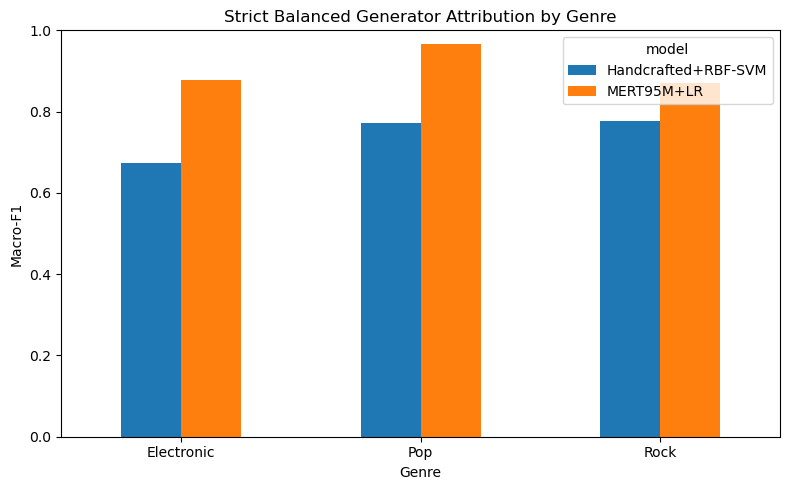

Saved: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/generator_genre_feature_analysis/generator_attribution_macro_f1_by_genre.png


In [10]:

pivot = genre_perf.pivot(
    index="genre",
    columns="model",
    values="macro_f1",
)

ax = pivot.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_ylim(0, 1.0)
ax.set_ylabel("Macro-F1")
ax.set_xlabel("Genre")
ax.set_title("Strict Balanced Generator Attribution by Genre")
ax.tick_params(axis="x", rotation=0)

fig = ax.get_figure()
fig.tight_layout()

fig_path = RESULT_DIR / "generator_attribution_macro_f1_by_genre.png"

fig.savefig(
    fig_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig_path)

## 11. 결과 저장 / 최종 QC

In [11]:

genre_perf.to_csv(
    RESULT_DIR / "genre_model_performance.csv",
    index=False,
    encoding="utf-8-sig",
)

gen_genre_recall.to_csv(
    RESULT_DIR / "generator_genre_recall.csv",
    index=False,
    encoding="utf-8-sig",
)

genre_sensitivity.to_csv(
    RESULT_DIR / "generator_genre_sensitivity.csv",
    index=False,
    encoding="utf-8-sig",
)

feature_stats.to_csv(
    RESULT_DIR / "handcrafted_feature_anova.csv",
    index=False,
    encoding="utf-8-sig",
)

group_stats.to_csv(
    RESULT_DIR / "handcrafted_feature_group_anova.csv",
    index=False,
    encoding="utf-8-sig",
)

cross_genre.to_csv(
    RESULT_DIR / "cross_genre_discriminative_features.csv",
    index=False,
    encoding="utf-8-sig",
)

qc = pd.DataFrame(
    {
        "check": [
            "strict_tracks",
            "feature_count",
            "mert_layer",
            "genre_perf_rows",
            "generator_genre_rows",
            "feature_stats_rows",
            "cross_genre_rows",
            "genre_plot_exists",
        ],
        "value": [
            len(strict_tracks),
            len(feature_cols),
            BEST_MERT_LAYER,
            len(genre_perf),
            len(gen_genre_recall),
            len(feature_stats),
            len(cross_genre),
            (RESULT_DIR / "generator_attribution_macro_f1_by_genre.png").exists(),
        ],
    }
)

display(qc)

core_qc = (
    len(strict_tracks) == 1428
    and len(feature_cols) == 266
    and BEST_MERT_LAYER == 10
    and len(genre_perf) == 6
    and len(feature_stats) == 266
    and len(cross_genre) == 266
)

print("===== FINAL RESULT =====")
print(
    "Generator × Genre / Feature Analysis Core QC PASS:",
    core_qc,
)

,check,value
0,strict_tracks,1428
1,feature_count,266
2,mert_layer,10
3,genre_perf_rows,6
4,generator_genre_rows,72
5,feature_stats_rows,266
6,cross_genre_rows,266
7,genre_plot_exists,True


===== FINAL RESULT =====
Generator × Genre / Feature Analysis Core QC PASS: True


## 장르와 특징 결과

[장르별 Macro-F1](../results/generator_genre_feature_analysis/genre_model_performance.csv)과 [생성기×장르 재현율](../results/generator_genre_feature_analysis/generator_genre_recall.csv)을 함께 보면 표본 수가 적은 조합을 확인할 수 있다. [ANOVA 특징 표](../results/generator_genre_feature_analysis/handcrafted_feature_anova.csv)는 Train에서 계산한 특징별 연관성이고, 모델의 내부 중요도나 생성기의 고유 원인을 뜻하지 않는다.